# Download e visão inicial dos dados

In [2]:
!pip install seaborn

In [31]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


In [12]:

data_dir = Path.cwd() / "data"   # Path.cwd() = diretório do notebook
data_dir.mkdir(exist_ok=True)

symbol = 'MSFT'
start_date = '2024-01-01'
end_date = '2025-10-31'

df = yf.download(symbol, start=start_date, end=end_date)
df.to_csv(data_dir / "MSFT.csv", index=False)

/var/folders/22/p5w3pds139513tzr6pglg5_00000gn/T/ipykernel_1806/3763039313.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


## Carregandos dados locais

In [4]:
def load_stock(symbol):
    return pd.read_csv(f"data/{symbol}.csv")

In [5]:
df = load_stock("MSFT")

# Analise inicial

In [13]:
print('df info:')
print(df.info)

print(f'is there any NaN?: {df.isnull().any().any()}')


df info:
<bound method DataFrame.info of Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  365.421631  370.377735  361.381857  368.367696  25258600
2024-01-03  365.155579  367.776505  363.096286  363.588941  23083500
2024-01-04  362.534637  367.618836  361.775960  365.224542  20901500
2024-01-05  362.347443  366.594123  361.115806  363.549521  21004600
2024-01-08  369.185486  369.688003  363.588937  363.874655  23134000
...                ...         ...         ...         ...       ...
2025-10-24  522.631836  524.368576  519.737290  521.813360  15532400
2025-10-27  530.527100  533.581381  528.021779  530.786624  18734700
2025-10-28  541.057373  552.685573  539.759814  548.972552  29986700
2025-10-29  540.538330  545.249544  535.727327  543.922012  36023000
2025-10-30  524.777832  533.970588  521.144617  529.488985  41

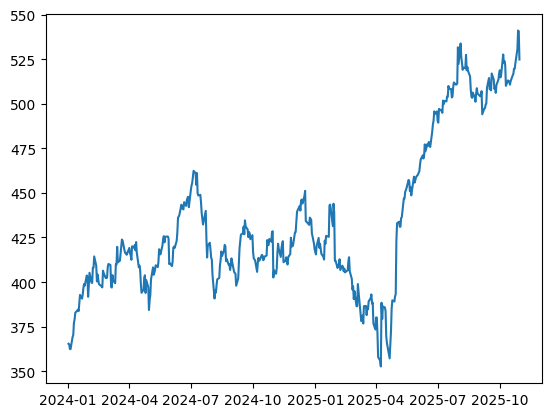

In [14]:
plt.plot(df['Close'])

In [15]:
print('df columns:')
print(df.columns)


df columns:
MultiIndex([( 'Close', 'MSFT'),
            (  'High', 'MSFT'),
            (   'Low', 'MSFT'),
            (  'Open', 'MSFT'),
            ('Volume', 'MSFT')],
           names=['Price', 'Ticker'])


In [16]:
# tirando o segundo nível das colunas
df.columns = df.columns.get_level_values('Price')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2024-01-02,365.421631,370.377735,361.381857,368.367696,25258600
2024-01-03,365.155579,367.776505,363.096286,363.588941,23083500
2024-01-04,362.534637,367.618836,361.775960,365.224542,20901500
2024-01-05,362.347443,366.594123,361.115806,363.549521,21004600
2024-01-08,369.185486,369.688003,363.588937,363.874655,23134000
...,...,...,...,...,...
2025-10-24,522.631836,524.368576,519.737290,521.813360,15532400
2025-10-27,530.527100,533.581381,528.021779,530.786624,18734700
2025-10-28,541.057373,552.685573,539.759814,548.972552,29986700


In [17]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

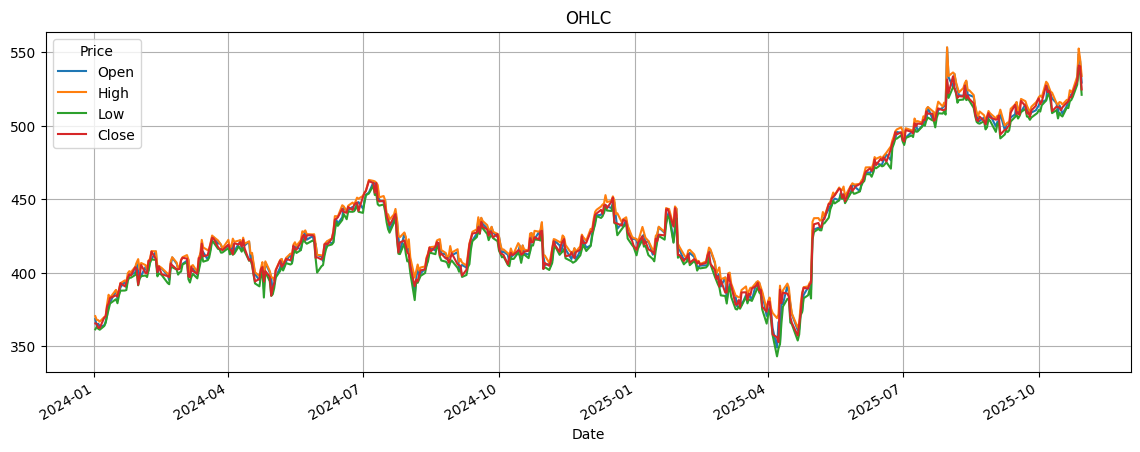

In [18]:
df[['Open', 'High', 'Low', 'Close']].plot(figsize=(14,5))
plt.title("OHLC")
plt.grid(True)
plt.show()


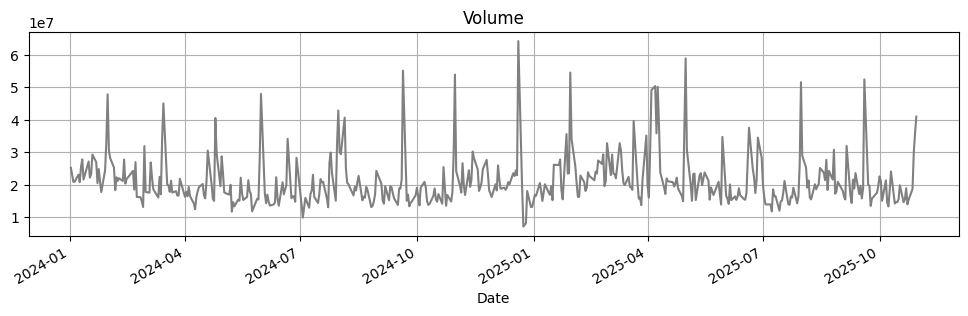

In [19]:
df['Volume'].plot(figsize=(12,3), color='gray')
plt.title("Volume")
plt.grid(True)
plt.show()


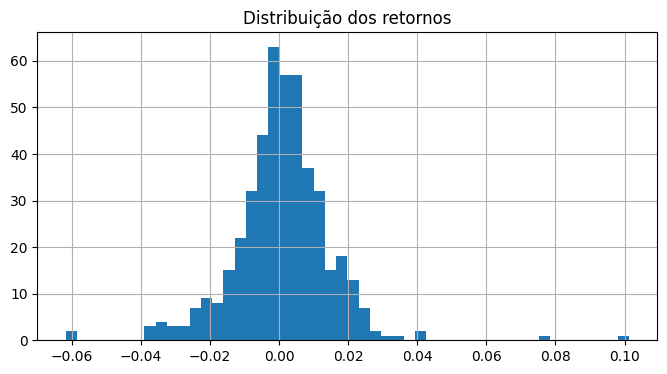

In [20]:
returns = df['Close'].pct_change()
returns.hist(bins=50, figsize=(8,4))
plt.title("Distribuição dos retornos")
plt.grid(True)
plt.show()


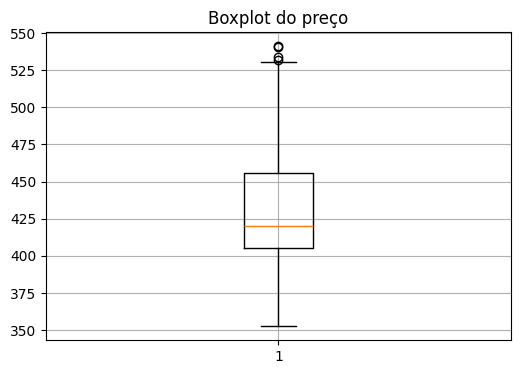

In [21]:
plt.figure(figsize=(6,4))
plt.boxplot(df['Close'].dropna())
plt.title("Boxplot do preço")
plt.grid(True)
plt.show()


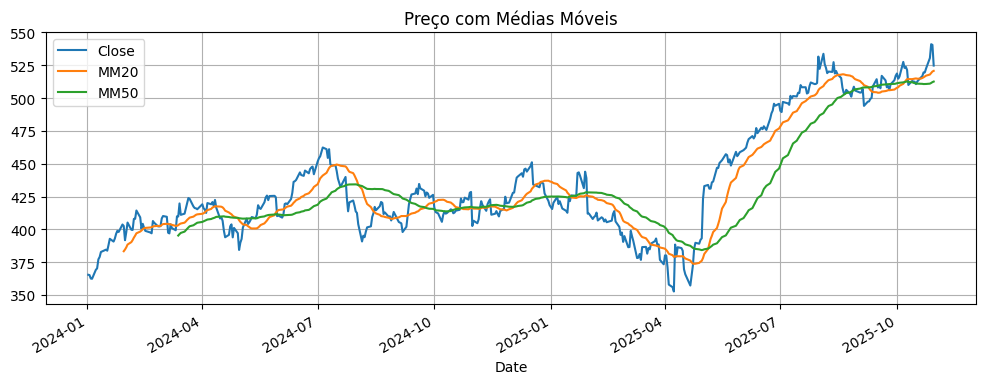

In [22]:
df['Close'].plot(figsize=(12,4), label="Close")
df['Close'].rolling(20).mean().plot(label="MM20")
df['Close'].rolling(50).mean().plot(label="MM50")

plt.title("Preço com Médias Móveis")
plt.legend()
plt.grid(True)
plt.show()


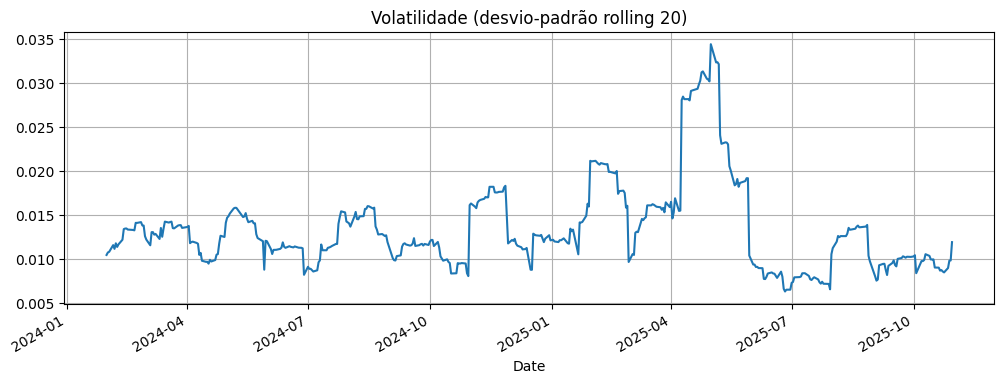

In [23]:
vol = returns.rolling(20).std()

vol.plot(figsize=(12,4))
plt.title("Volatilidade (desvio-padrão rolling 20)")
plt.grid(True)
plt.show()


# Tratando outliers

In [24]:
# Criando função para tratar outliers

def cap_outliers(df, cols, factor=1.5):
    df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        print(f'{col} limits: lower: {lower} upper: {upper}')

        df[col] = df[col].clip(lower, upper) #Valores menores que lower são substituídos por lower. Valores maiores que upper são substituídos por upper. Mantém o tamanho do DataFrame → essencial para LSTM. Evita excluir linhas e quebrar a sequência temporal.
    return df


In [25]:
df_sem_outliers = cap_outliers(df, df.columns)

Close limits: lower: 330.4282760620117 upper: 530.8386154174805
High limits: lower: 333.7919758791267 upper: 533.8218275269955
Low limits: lower: 325.9742650011789 upper: 528.8090454176316
Open limits: lower: 331.7281452275698 upper: 527.5596807209766
Volume limits: lower: 5844875.0 upper: 33769275.0


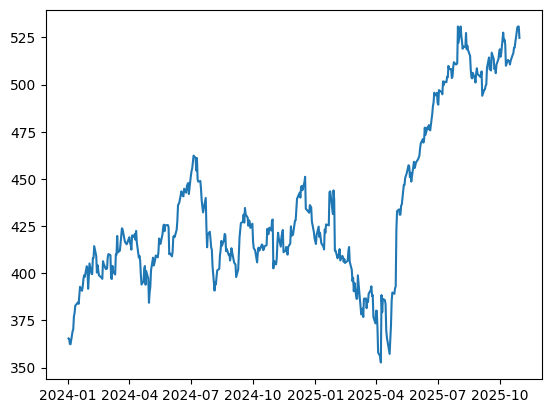

In [26]:
plt.plot(df_sem_outliers['Close'])

# Alternativa 1: Apenas Transformando Dados

In [30]:
# para LSTM (treino = passado / teste = futuro), você separa X e y depois de criar as janelas (windows).

train_size = int(len(df_sem_outliers) * 0.8)

train = df_sem_outliers.iloc[:train_size]
test  = df_sem_outliers.iloc[train_size:]


In [31]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train)
test_scaled  = scaler.transform(test)


In [37]:
print(f"transformed shape: {train.shape}")
print(f"per-feature minimum before scaling: \n {train.min(axis=0)}")
print(f"per-feature maximum before scaling: \n {train.max(axis=0)}")
print(f"per-feature minimum after scaling: \n {train_scaled.min(axis=0)}")
print(f"per-feature maximum after scaling: \n {train_scaled.max(axis=0)}")

transformed shape: (368, 5)
per-feature minimum before scaling: 
 Price
Close     3.526694e+02
High      3.625365e+02
Low       3.429515e+02
Open      3.490090e+02
Volume    7.164500e+06
dtype: float64
per-feature maximum before scaling: 
 Price
Close     4.785561e+02
High      4.817649e+02
Low       4.751980e+02
Open      4.805392e+02
Volume    3.376928e+07
dtype: float64
per-feature minimum after scaling: 
 [0. 0. 0. 0. 0.]
per-feature maximum after scaling: 
 [1. 1. 1. 1. 1.]


In [38]:
print(f"transformed shape: {test.shape}")
print(f"per-feature minimum before scaling: \n {test.min(axis=0)}")
print(f"per-feature maximum before scaling: \n {test.max(axis=0)}")
print(f"per-feature minimum after scaling: \n {test_scaled.min(axis=0)}")
print(f"per-feature maximum after scaling: \n {test_scaled.max(axis=0)}")

transformed shape: (92, 5)
per-feature minimum before scaling: 
 Price
Close     4.842960e+02
High      4.860398e+02
Low       4.708533e+02
Open      4.765333e+02
Volume    1.184660e+07
dtype: float64
per-feature maximum before scaling: 
 Price
Close     5.308387e+02
High      5.338219e+02
Low       5.288091e+02
Open      5.275597e+02
Volume    3.376928e+07
dtype: float64
per-feature minimum after scaling: 
 [1.04559525 1.0358553  0.96714698 0.9695437  0.17598721]
per-feature maximum after scaling: 
 [1.41531402 1.4366161  1.40538777 1.35748838 1.        ]


In [32]:
# Para LSTMs, você nunca usa “linha atual” como X — você usa um histórico (window).
# Exemplo: usar 30 passos passados para prever o próximo passo.

def create_sequences_multivar(data, window, target_col_index):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])      # janela com as 5 features
        y.append(data[i, target_col_index]) # apenas o Close
    return np.array(X), np.array(y)


In [33]:
# Você deve criar as janelas separadamente, pois misturar test com train faz vazamento de dados.

window = 30
target_col_index = 0  # "Close"

X_train, y_train = create_sequences_multivar(train_scaled, window, target_col_index)
X_test, y_test   = create_sequences_multivar(test_scaled, window, target_col_index)

In [35]:
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (338, 30, 5)
y_train shape: (338,)
y_test shape: (62, 30, 5)
y_test shape: (62,)


# Alternativa 2: Transformando dados e treinando modelo


In [27]:
# Para LSTMs, você nunca usa “linha atual” como X — você usa um histórico (window).
# Exemplo: usar 30 passos passados para prever o próximo passo.

def create_sequences_multivar(data, window, target_col_index):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i, :])      # janela com as 5 features
        y.append(data[i, target_col_index]) # apenas o Close
    return np.array(X), np.array(y)


In [28]:
tscv = TimeSeriesSplit(n_splits=5)
window = 30
target_col_index = 0  # "Close"

In [32]:
for split_idx, (train_idx, val_idx) in enumerate(tscv.split(df)):
    print(f"\n=== Split {split_idx+1} ===")

    # 1 — Divisão temporal do DataFrame original
    train_df = df.iloc[train_idx]
    val_df   = df.iloc[val_idx]

    # 2 — Normalização (fit no train, transform no val)
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_df)
    val_scaled   = scaler.transform(val_df)

    # 3 — Criar janelas apenas dentro de cada split
    X_train, y_train = create_sequences_multivar(train_scaled, window, target_col_index)
    X_val, y_val     = create_sequences_multivar(val_scaled, window, target_col_index)

    # Ajuste: remover splits muito pequenos para janela
    if len(X_train) == 0 or len(X_val) == 0:
        print("Split muito pequeno para janela — pulando.")
        continue

    # 4 — Criar o modelo LSTM
    model = Sequential([
        LSTM(64, input_shape=(window, df.shape[1])),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")

    # 5 — Treinar
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_val, y_val),
        verbose=1
    )

    # 6 — Avaliar para esse split
    val_loss = model.evaluate(X_val, y_val, verbose=0)
    print(f"Val Loss Split {split_idx+1}: {val_loss:.6f}")


    # ---- 7 — Previsões ----
    y_pred_scaled = model.predict(X_val)

    # ---- 8 — Precisamos inverter a escala (voltar ao valor original) ----
    # O MinMaxScaler foi treinado com todas as features, então precisamos
    # recolocar as previsões dentro de matrizes completas para inverse_transform.

    # Criar arrays cheios de zeros para reconstruir a estrutura original
    dummy_pred  = np.zeros((len(y_pred_scaled), df.shape[1]))
    dummy_true  = np.zeros((len(y_val), df.shape[1]))

    # Colocar apenas a coluna alvo no lugar correto
    dummy_pred[:, target_col_index] = y_pred_scaled[:, 0]
    dummy_true[:, target_col_index] = y_val

    # Inverter normalização apenas da coluna alvo
    y_pred = scaler.inverse_transform(dummy_pred)[:, target_col_index]
    y_true = scaler.inverse_transform(dummy_true)[:, target_col_index]

    # ---- 9 — Calcular métricas ----
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"RMSE Split {split_idx+1}: {rmse:.4f}")
    print(f"MAPE Split {split_idx+1}: {mape:.2f}%")



=== Split 1 ===


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 647ms/step - loss: 1.4355 - val_loss: 2.2382
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.9494 - val_loss: 1.4836
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.5893 - val_loss: 0.9212
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.3219 - val_loss: 0.5068
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.1443 - val_loss: 0.2293
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.0417 - val_loss: 0.0986
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.0223 - val_loss: 0.0950
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0693 - val_loss: 0.1151
Epoch 9/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - loss: 0.0910 - val_loss: 0.1010
Epoch 10/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.0723 - val_loss: 0.0807
Epoch 11/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 0.0437 - val_loss: 0.0759
Epoch 12/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - loss: 0.0236 - val_lo

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - loss: 0.2356 - val_loss: 0.0343
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0283 - val_loss: 0.0400
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0497 - val_loss: 0.0372
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0250 - val_loss: 0.0070
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0132 - val_loss: 0.0071
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0171 - val_loss: 0.0085
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0165 - val_loss: 0.0062
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0127 - val_loss: 0.0055
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0102 - val_loss: 0.0071
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0109 - val_loss: 0.0077
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0107 - val_loss: 0.0068
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0098 - val_loss: 0.0056
Epoch 13/20

...

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - loss: 0.1899 - val_loss: 0.0174
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0382 - val_loss: 0.0405
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0138 - val_loss: 0.0107
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0153 - val_loss: 0.0111
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0114 - val_loss: 0.0117
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0092 - val_loss: 0.0141
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0088 - val_loss: 0.0108
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0083 - val_loss: 0.0099
Epoch 9/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0079 - val_loss: 0.0104
Epoch 10/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0078 - val_loss: 0.0107
Epoch 11/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0073 - val_loss: 0.0097
Epoch 12/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0072 - val_loss: 0.0094
Epoch 13/20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0888 - val_loss: 0.0046
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0205 - val_loss: 0.0684
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0127 - val_loss: 0.0808
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0086 - val_loss: 0.0255
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0089 - val_loss: 0.0304
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0078 - val_loss: 0.0433
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0076 - val_loss: 0.0292
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0073 - val_loss: 0.0260
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0071 - val_loss: 0.0280
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0070 - val_loss: 0.0230
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0068 - val_loss: 0.0216
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0066 - val_loss: 0.0176
E

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - loss: 0.0160 - val_loss: 0.0445
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0071 - val_loss: 0.0026
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0052 - val_loss: 0.0021
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0043 - val_loss: 0.0097
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0040 - val_loss: 0.0036
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0039 - val_loss: 0.0018
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0040 - val_loss: 0.0027
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0035 - val_loss: 0.0017
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0033 - val_loss: 0.0017
Epoch 10/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0033 - val_loss: 0.0017
Epoch 11/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0030 - val_loss: 0.0036
Epoch 12/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0